# Milestone 2

## **1.PERKENALAN**

A. Perkenalan Identitas

Nama : Nur Cahyo Widodo  
Batch : Batch 035 (Pondok Indah)  
Topik : Gym Membership Churn Prediction

B. Latar Belakang  

Bisnis gym dan fitness center berbasis sistem keanggotaan (membership) sangat bergantung pada kemampuan perusahaan dalam mempertahankan member agar tetap aktif berlangganan. Ketika seorang member berhenti (churn), gym tidak hanya kehilangan pendapatan rutin, tetapi juga harus mengeluarkan biaya tambahan untuk memperoleh member baru. Oleh karena itu, memahami pola perilaku member yang berpotensi berhenti (churn) menjadi hal yang penting untuk mendukung pengambilan keputusan bisnis.

Dataset yang digunakan dalam project ini berisi data member gym yang mencakup informasi demografis, durasi kontrak, frekuensi kunjungan, serta aktivitas penggunaan fasilitas gym. Data ini dapat dimanfaatkan untuk mengidentifikasi karakteristik member yang cenderung berhenti berlangganan. Dengan pendekatan klasifikasi, diharapkan dapat dibangun sebuah model yang mampu memprediksi kemungkinan seorang member akan melakukan churn atau tidak. Hasil prediksi ini dapat digunakan sebagai dasar dalam menyusun strategi retensi yang lebih tepat sasaran.

C. Dataset

Dataset yang digunakan pada project ini diperoleh dari platform Kaggle dengan judul “Churn Prediction Gym Members Dataset”. Dataset ini terdiri dari lebih dari 10 kolom dengan kombinasi fitur numerik dan kategorikal, seperti usia member, jarak tempat tinggal ke gym, durasi kontrak, frekuensi kelas, serta aktivitas tambahan yang dilakukan oleh member. Target variabel pada dataset ini adalah status churn, yang menunjukkan apakah seorang member berhenti berlangganan atau tetap aktif.

D. Tujuan

Untuk memprediksi apakah seorang member gym berpotensi melakukan churn atau tidak berdasarkan data historis keanggotaan dan aktivitas member. Model ini diharapkan dapat membantu pihak gym dalam mengidentifikasi member yang berisiko berhenti lebih awal sehingga strategi retensi dapat dilakukan dengan lebih tepat.

## **2. IMPORT LIBRARIES**

Pada tahap ini, dilakukan proses import seluruh library yang akan digunakan dalam project. Library yang diimpor mencakup kebutuhan untuk manipulasi data, visualisasi, preprocessing, pembuatan model machine learning, evaluasi model, hingga penyimpanan model.

In [75]:
# Library untuk manipulasi data
import pandas as pd              # Mengelola data dalam bentuk DataFrame
import numpy as np               # Operasi numerik dan array

# Library untuk visualisasi data
import matplotlib.pyplot as plt  # Visualisasi dasar
import seaborn as sns            # Visualisasi statistik

# Library untuk preprocessing dan splitting data
from sklearn.model_selection import train_test_split  # Split data
from sklearn.model_selection import StratifiedKFold, cross_val_score #cross validation
from sklearn.preprocessing import StandardScaler, OneHotEncoder         # Scaling & encoding
from sklearn.compose import ColumnTransformer                            # Menggabungkan preprocessing
from sklearn.pipeline import Pipeline                                    # Membuat pipeline
from sklearn.impute import SimpleImputer

# Library model machine learning
from sklearn.neighbors import KNeighborsClassifier       # Model KNN
from sklearn.svm import SVC                               # Model SVM
from sklearn.tree import DecisionTreeClassifier           # Model Decision Tree
from sklearn.ensemble import RandomForestClassifier       # Model Random Forest
from sklearn.ensemble import GradientBoostingClassifier   # Model Boosting
from sklearn.linear_model import LogisticRegression

# Library untuk evaluasi model
from sklearn.metrics import classification_report         # Laporan evaluasi klasifikasi
from sklearn.metrics import confusion_matrix              # Confusion matrix
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, auc               # Accuracy score


# Library untuk hyperparameter tuning
from sklearn.model_selection import GridSearchCV          # Grid Search CV

# Library untuk menyimpan dan memuat model
import joblib                                             # Save & load model


## **3. DATA LOADING**

Pada tahap ini dilakukan proses pemuatan dataset serta pengecekan awal untuk memahami struktur data yang digunakan. Proses ini bertujuan untuk mengetahui ukuran dataset, tipe data pada setiap kolom, serta memastikan data siap untuk dilakukan eksplorasi lebih lanjut

In [76]:
# membaca dataset dari file CSV
df = pd.read_csv('P1M2_Nur_Cahyo_Widodo_dataset.csv')

df

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,Mohammed,54.0,Male,"Street 2, City 15",036-24733357,Quarterly,2023-12-10,2024-04-27,Pull-ups,64,733.0,6082.0,14.0,No
146,147,Haseena,45.0,Female,"Street 31, City 22",038-73797777,Monthly,2023-02-10,2023-04-02,Bench Press,95,641.0,7375.0,12.0,No
147,148,Hassaan,54.0,Male,"Street 121, City 31",032-16612823,Quarterly,2023-03-27,2023-12-07,Deadlift,80,471.0,6138.0,14.0,No
148,149,Najat,26.0,Female,"Street 190, City 9",034-49625944,Monthly,2023-05-05,2024-03-26,Bench Press,50,473.0,18336.0,4.0,Yes


In [77]:
# Menampilkan 10 data pertama
df.head(10)

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No
5,6,Arsalan Zafar,53.0,Male,"Street 15, City 27",035-95902365,Quarterly,2022-06-07,2022-09-12,Deadlift,102,250.0,4631.0,23.0,No
6,7,Kumail,46.0,Male,"Street 35, City 1",039-95163386,Monthly,2023-05-14,2023-07-10,Squats,33,NaN,4926.0,7.0,Yes
7,8,Jahanzaib,36.0,Male,"Street 25, City 14",039-51007076,Monthly,2022-02-06,2022-05-06,Deadlift,112,722.0,18376.0,16.0,No
8,9,M. Talha,41.0,Male,"Street 170, City 15",035-81198701,Quarterly,2022-08-25,2023-08-23,Squats,42,226.0,13622.0,22.0,No
9,10,Ayesha,NaN,Female,"Street 127, City 31",034-55245029,Monthly,2022-03-24,2022-06-26,Pull-ups,74,NaN,2113.0,19.0,No


In [78]:
# Menampilkan 10 data terakhir
df.tail(10)

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
140,141,NaN,27.0,Male,"Street 72, City 39",031-88717607,Monthly,2024-09-23,2025-04-08,Deadlift,86,274.0,2346.0,8.0,No
141,142,Tasneem,23.0,Female,"Street 61, City 38",038-39022969,Monthly,2022-11-24,2023-09-01,Bench Press,58,NaN,2224.0,21.0,No
142,143,Nawal,36.0,Female,"Street 199, City 21",037-27944764,Quarterly,2024-05-25,2025-05-15,Cycling,49,338.0,14846.0,18.0,No
143,144,NaN,18.0,Male,"Street 128, City 49",039-37003061,Yearly,2024-07-19,2024-10-06,Squats,113,538.0,10700.0,9.0,No
144,145,Sajid,22.0,Male,"Street 161, City 7",039-30173428,Yearly,2023-04-25,2023-10-27,Squats,116,441.0,7013.0,6.0,Yes
145,146,Mohammed,54.0,Male,"Street 2, City 15",036-24733357,Quarterly,2023-12-10,2024-04-27,Pull-ups,64,733.0,6082.0,14.0,No
146,147,Haseena,45.0,Female,"Street 31, City 22",038-73797777,Monthly,2023-02-10,2023-04-02,Bench Press,95,641.0,7375.0,12.0,No
147,148,Hassaan,54.0,Male,"Street 121, City 31",032-16612823,Quarterly,2023-03-27,2023-12-07,Deadlift,80,471.0,6138.0,14.0,No
148,149,Najat,26.0,Female,"Street 190, City 9",034-49625944,Monthly,2023-05-05,2024-03-26,Bench Press,50,473.0,18336.0,4.0,Yes
149,150,Nuha,43.0,Male,"Street 87, City 6",035-30033575,Yearly,2024-06-02,2025-05-22,Squats,78,608.0,12542.0,22.0,No


Penampilan 10 data pertama dan 10 data terakhir dilakukan untuk memastikan bahwa dataset berhasil dimuat dengan benar. Selain itu, langkah ini membantu melihat gambaran awal struktur data serta memastikan tidak ada kejanggalan pada urutan atau isi data.

In [79]:
# melihat ukuran dataset
df.shape

(150, 15)

Informasi ukuran dataset digunakan untuk mengetahui jumlah baris dan kolom yang
akan dianalisis serta memastikan dataset berhasil dimuat dengan baik.

In [80]:
# Informasi struktur data dan tipe kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

Pemeriksaan struktur dataset dilakukan untuk mengetahui tipe data pada setiap kolom, jumlah data, serta mendeteksi kemungkinan adanya missing value pada dataset.

In [81]:
# melihat statistik deskriptif
df.describe()

,Member_ID,Age,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month
count,150.000000,137.000000,150.000000,139.000000,142.000000,138.000000
mean,75.500000,35.905109,73.326667,488.309353,9486.978873,14.224638
std,43.445368,11.654892,25.879560,168.649317,5127.955128,6.385451
min,1.000000,18.000000,30.000000,209.000000,1009.000000,4.000000
25%,38.250000,25.000000,53.000000,341.500000,5274.000000,8.000000
50%,75.500000,36.000000,74.000000,496.000000,9072.500000,14.000000
75%,112.750000,46.000000,94.500000,627.500000,13620.750000,20.000000
max,150.000000,54.000000,119.000000,788.000000,19722.000000,24.000000


Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai distribusi data numerik, seperti nilai minimum, maksimum, rata-rata, dan sebaran data.

In [82]:
# Mengecek jumlah missing value pada setiap kolom
df.isna().sum()

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64

Berdasarkan hasil pengecekan missing value, terdapat beberapa kolom yang memiliki data kosong, yaitu `Name`, `Age`, `Join_Date`, `Avg_Workout_Duration_Min`, `Total_Weight_Lifted_kg`, dan `Visits_Per_Month`. Sementara itu, kolom target `Churn` tidak memiliki missing value.

Keberadaan missing value ini akan ditangani pada tahap Feature Engineering agar
tidak memengaruhi proses pelatihan dan evaluasi model.

In [83]:
# mengecek jumlah data duplikat
df.duplicated().sum()

0

Pengecekan data duplikat dilakukan untuk memastikan tidak terdapat baris data yang terduplikasi, yang dapat memengaruhi kualitas dan keandalan model.

## **4.EXPLORATORY DATA ANALYSIS (EDA)**

Tahap Exploratory Data Analysis dilakukan untuk memahami karakteristik data serta pola yang berkaitan dengan churn member gym. Analisis difokuskan pada hubungan antara fitur dengan target variabel churn guna memperoleh analisis yang relevan.

### 4.1 Bagaimana distribusi target `Churn` pada dataset?

Pertanyaan ini bertujuan untuk melihat distribusi variabel target `Churn` guna
mengetahui apakah dataset bersifat seimbang (balanced) atau tidak. Informasi ini
penting karena distribusi target dapat memengaruhi pemilihan metrik evaluasi dan
kinerja model klasifikasi.

In [84]:
# Menampilkan jumlah member berdasarkan status churn
df['Churn'].value_counts()

Churn
No     111
Yes     39
Name: count, dtype: int64

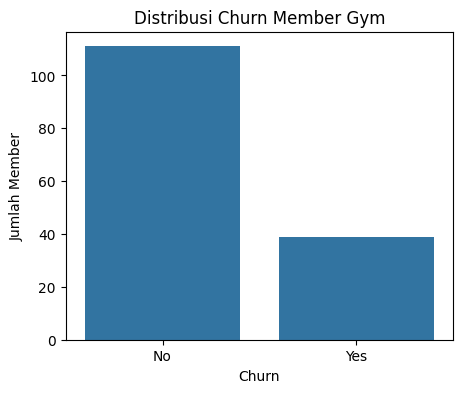

In [85]:
# Visualisasi distribusi target churn
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn Member Gym')
plt.xlabel('Churn')
plt.ylabel('Jumlah Member')
plt.show()

Berdasarkan visualisasi distribusi `Churn`, terlihat bahwa jumlah member yang tidak berhenti membership (`No`) jauh lebih banyak dibandingkan member yang berhenti (`Yes`).

### 4.2 Apakah usia (`Age`) memiliki hubungan dengan status churn?

Pertanyaan ini bertujuan untuk menganalisis hubungan antara usia member dengan status churn. Analisis ini dilakukan untuk melihat apakah terdapat perbedaan distribusi usia antara member yang churn dan yang tidak churn.

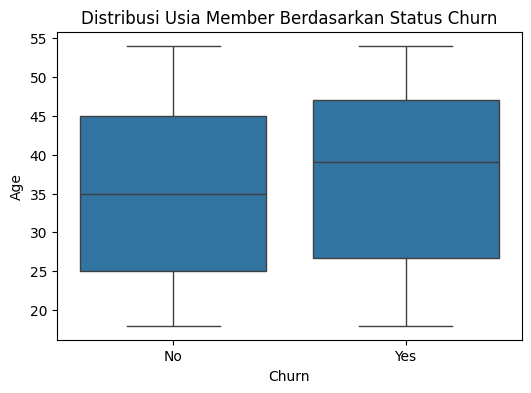

In [86]:
# Visualisasi Age vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Age', data=df)
plt.title('Distribusi Usia Member Berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Age')
plt.show()

Berdasarkan visualisasi tersebut, terlihat bahwa distribusi usia antara member yang churn dan tidak churn relatif mirip. Median usia member yang churn sedikit lebih tinggi dibandingkan member yang tidak churn, namun perbedaannya tidak terlalu signifikan.

Hal ini menunjukkan bahwa variabel usia (`Age`) tidak menjadi faktor dominan dalam menentukan churn secara tunggal. Namun, variabel ini tetap berpotensi memberikan kontribusi ketika dikombinasikan dengan variabel lain pada proses pemodelan.

### 4.3 Apakah tipe keanggotaan (`Membership_Type`) memiliki hubungan dengan status churn?

Pertanyaan ini bertujuan untuk menganalisis hubungan antara tipe keanggotaan gym
dengan status churn. Analisis ini dilakukan untuk mengetahui apakah jenis membership tertentu memiliki kecenderungan churn yang lebih tinggi dibandingkan yang lain.

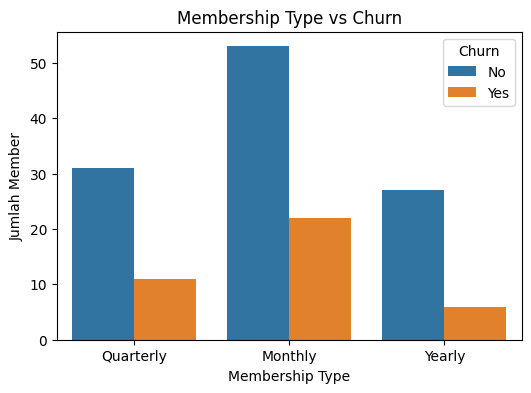

In [87]:
# Visualisasi hubungan antara tipe membership dan status churn
plt.figure(figsize=(6,4))
sns.countplot(x='Membership_Type', hue='Churn', data=df)
plt.title('Membership Type vs Churn')
plt.xlabel('Membership Type')
plt.ylabel('Jumlah Member')
plt.legend(title='Churn')
plt.show()

Berdasarkan visualisasi, terlihat bahwa member dengan tipe keanggotaan **Monthly** memiliki jumlah churn paling tinggi dibandingkan tipe lainnya. Sementara itu, member dengan keanggotaan **Yearly** menunjukkan jumlah churn yang paling rendah.

Pola ini mengindikasikan bahwa member dengan komitmen jangka pendek cenderung lebih mudah berhenti berlangganan, sedangkan member dengan komitmen jangka panjang memiliki tingkat retensi yang lebih baik. Oleh karena itu, variabel `Membership_Type` memiliki peran penting dalam memprediksi churn dan relevan untuk dijadikan fitur pada model.

### 4.4 Apakah frekuensi kunjungan (`Visits_Per_Month`) berhubungan dengan status churn?

Pertanyaan ini bertujuan untuk menganalisis hubungan antara frekuensi kunjungan member ke gym dengan status churn. Analisis ini dilakukan untuk melihat apakah member yang lebih jarang berkunjung memiliki kecenderungan churn yang lebih tinggi.

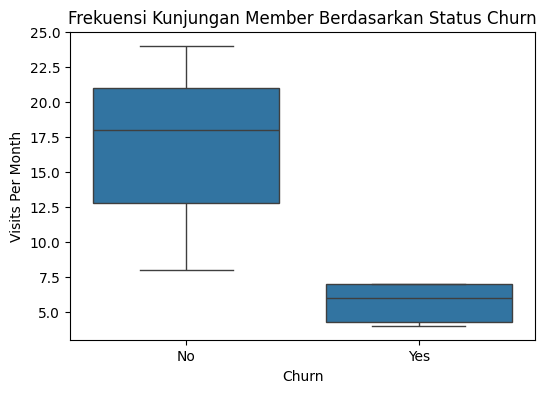

In [88]:
# Visualisasi distribusi frekuensi kunjungan per bulan berdasarkan status churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Visits_Per_Month', data=df)
plt.title('Frekuensi Kunjungan Member Berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Visits Per Month')
plt.show()

Berdasarkan visualisasi boxplot, terlihat perbedaan yang sangat jelas antara frekuensi kunjungan member yang churn dan yang tidak churn. Member yang churn memiliki frekuensi kunjungan yang jauh lebih rendah dibandingkan member yang tetap aktif.

Distribusi ini menunjukkan bahwa frekuensi kunjungan merupakan indikator kuat tingkatketerlibatan member. Member dengan intensitas kunjungan yang rendah cenderung memiliki risiko churn yang lebih tinggi. Oleh karena itu, variabel `Visits_Per_Month` sangat relevan dan berpotensi menjadi salah satu fitur penting dalam proses pemodelan churn.


### 4.5 Apakah durasi workout rata-rata (`Avg_Workout_Duration_Min`) berhubungan dengan status churn?

Pertanyaan ini bertujuan untuk menganalisis hubungan antara durasi workout rata-rata member dengan status churn. Analisis ini dilakukan untuk melihat apakah member dengan durasi latihan yang lebih singkat cenderung memiliki risiko churn yang lebih tinggi.

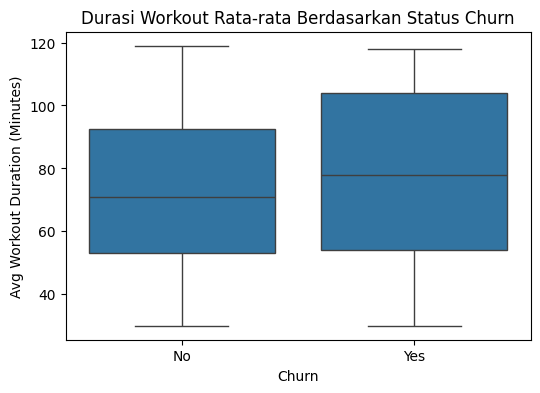

In [89]:
# Visualisasi distribusi durasi workout rata-rata berdasarkan status churn

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Avg_Workout_Duration_Min', data=df)
plt.title('Durasi Workout Rata-rata Berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Avg Workout Duration (Minutes)')
plt.show()

Berdasarkan visualisasi boxplot, terlihat bahwa member yang churn justru memiliki durasi workout rata-rata yang sedikit lebih tinggi dibandingkan member yangtidak churn. Hal ini menunjukkan bahwa durasi workout yang lebih lama tidak selalu berkorelasi dengan loyalitas member.

Temuan ini mengindikasikan bahwa durasi workout perlu dilihat bersama dengan variabel lain, seperti frekuensi kunjungan. Member yang churn kemungkinan jarang datang ke gym, namun ketika datang melakukan workout dalam durasi yang lebih lama. Oleh karena itu, variabel `Avg_Workout_Duration_Min` tetap relevan, namun tidak dapat digunakan sebagai indikator churn secara tunggal.


### 4.6 Apakah jumlah kalori terbakar rata-rata (`Avg_Calories_Burned`) berbeda antara member yang churn dan tidak churn?

Pertanyaan ini bertujuan untuk menganalisis perbedaan jumlah kalori terbakar rata-rata antara member yang churn dan yang tidak churn. Variabel ini digunakan sebagai indikator intensitas aktivitas fisik member selama berolahraga di gym.

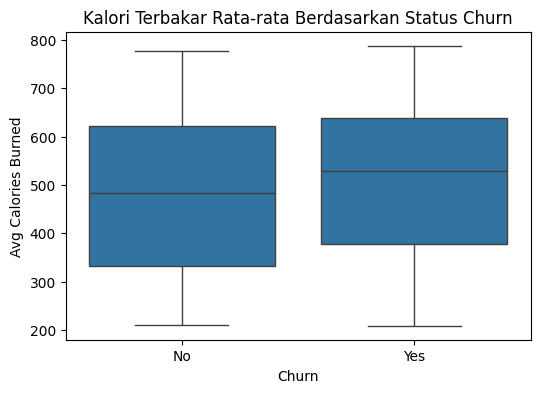

In [90]:
# Visualisasi distribusi kalori terbakar rata-rata berdasarkan status churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Avg_Calories_Burned', data=df)
plt.title('Kalori Terbakar Rata-rata Berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Avg Calories Burned')
plt.show()

Berdasarkan visualisasi boxplot, terlihat bahwa member yang churn memiliki jumlah kalori terbakar rata-rata yang sedikit lebih tinggi dibandingkan member yang tidak churn. Namun, rentang distribusi pada kedua kelompok menunjukkan overlap yang cukup besar.

Hal ini mengindikasikan bahwa jumlah kalori terbakar tidak menjadi pembeda yang kuat secara tunggal antara member yang churn dan yang tidak churn. Variabel ini lebih tepat dipandang sebagai indikator intensitas aktivitas fisik yang perlu dikombinasikan dengan variabel lain, seperti frekuensi kunjungan, dalam proses pemodelan churn.


### 4.7 Apakah jenis latihan favorit (`Favorite_Exercise`) memiliki pola churn tertentu?

Pertanyaan ini bertujuan untuk menganalisis apakah terdapat perbedaan pola churn
berdasarkan jenis latihan favorit member. Analisis ini dilakukan untuk melihat apakah jenis aktivitas tertentu memiliki kecenderungan churn yang lebih tinggi dibandingkan yang lain.

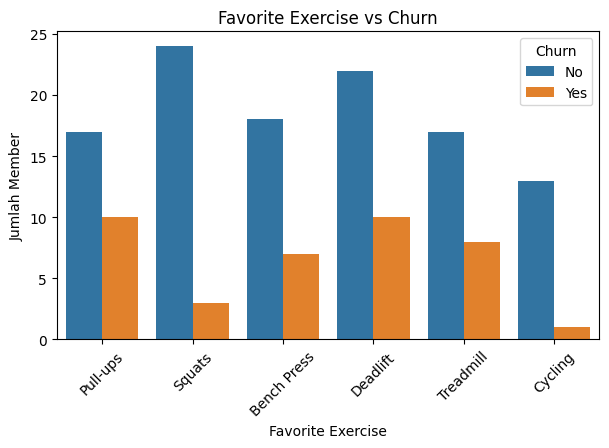

In [91]:
# Visualisasi hubungan antara jenis latihan favorit dan status churn
plt.figure(figsize=(7,4))
sns.countplot(
    x='Favorite_Exercise',
    hue='Churn',
    data=df
)
plt.title('Favorite Exercise vs Churn')
plt.xlabel('Favorite Exercise')
plt.ylabel('Jumlah Member')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

Berdasarkan visualisasi, terlihat bahwa pada seluruh jenis latihan favorit, jumlah member yang tidak churn (`No`) masih lebih dominan dibandingkan member yang churn (`Yes`). Namun, terdapat variasi jumlah churn pada beberapa jenis latihan.

Latihan seperti Pull-ups dan Deadlift menunjukkan jumlah churn yang relatif lebih tinggi dibandingkan jenis latihan lain, sementara Cycling memiliki jumlah churn yang paling rendah. Meskipun demikian, perbedaan ini tidak terlalu mencolok, sehingga jenis latihan favorit bukan merupakan faktor utama penentu churn.

Temuan ini menunjukkan bahwa variabel `Favorite_Exercise` memiliki kontribusi terbatas secara individual, namun tetap berpotensi memberikan informasi tambahan ketika dikombinasikan dengan variabel lain dalam proses pemodelan.


### Kenapa Pakai Visualisasi Ini?

Pemilihan jenis visualisasi pada tahap EDA disesuaikan dengan tipe data dan tujuan analisis. Untuk variabel numerik seperti `Age`, `Visits_Per_Month`, dan
`Avg_Workout_Duration_Min`, digunakan boxplot karena visualisasi ini efektif untuk menampilkan perbedaan distribusi, median, dan sebaran data antar kelompok churn.

Sementara itu, untuk variabel kategorikal seperti `Membership_Type` dan
`Favorite_Exercise`, digunakan countplot karena visualisasi ini memudahkan
perbandingan jumlah observasi pada setiap kategori berdasarkan status churn.
Pendekatan ini membantu dalam mengidentifikasi pola awal tanpa melakukan asumsi
statistik yang berlebihan.


### 4.8 Korelasi FItur Numerik

Analisis korelasi dilakukan untuk melihat hubungan antar fitur numerik serta
mengidentifikasi potensi multikolinearitas yang dapat memengaruhi proses pemodelan.

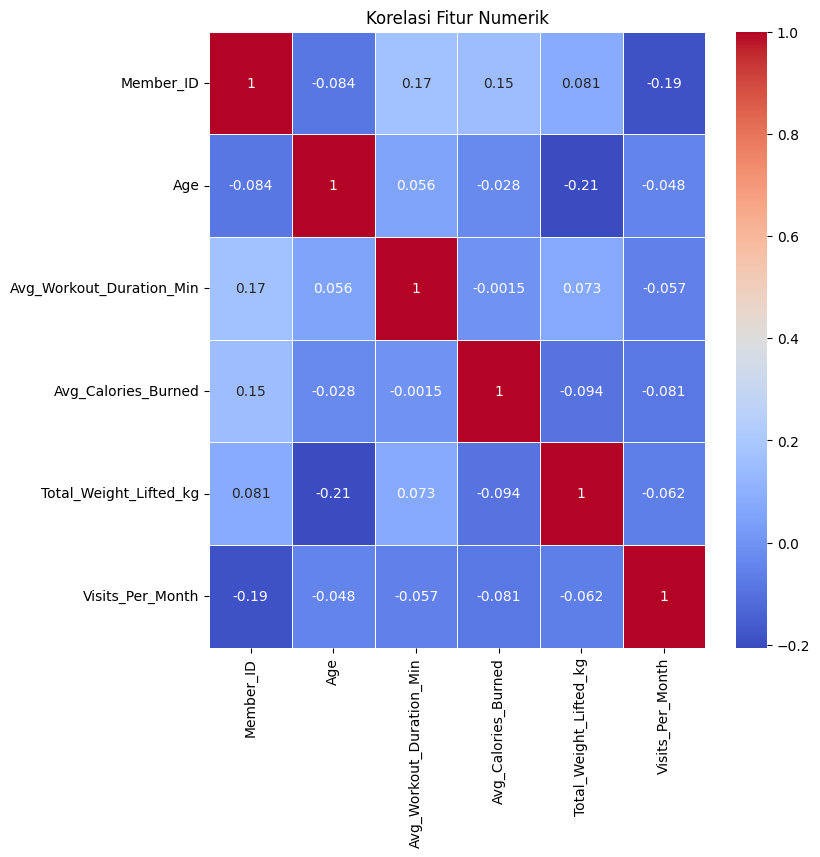

In [92]:
# Visualisasi korelasi antar fitur numerik

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(8, 8))
sns.heatmap(
    df[numerical_cols].corr(),
    cmap='coolwarm',
    linewidths=0.5,
    annot=True
)
plt.title('Korelasi Fitur Numerik')
plt.show()

Berdasarkan heatmap korelasi, terlihat bahwa sebagian besar fitur numerik memiliki nilai korelasi yang rendah satu sama lain. Tidak terdapat pasangan fitur dengan korelasi yang sangat tinggi, sehingga indikasi multikolinearitas pada dataset ini relatif kecil.

Hal ini menunjukkan bahwa fitur-fitur numerik yang digunakan cenderung memberikan informasi yang berbeda dan tidak redundan. Oleh karena itu, seluruh fitur numerik masih layak dipertahankan pada tahap pemodelan tanpa perlu menghilangkan fitur berdasarkan korelasi.

## **5. FEATURE ENGINEERING**

Pada tahap Feature Engineering, dilakukan proses persiapan data agar siap digunakan dalam pemodelan machine learning. Tahapan ini difokuskan pada pengambilan keputusan terkait pemilihan fitur, pengecekan karakteristik data, serta penentuan strategi preprocessing yang sesuai.

Seluruh proses preprocessing final seperti imputasi missing value, encoding, dan
feature scaling akan diimplementasikan menggunakan pipeline pada tahap pemodelan
untuk menghindari data leakage dan menjaga konsistensi proses pelatihan model.


### **5.1 Cardinality Check**

Cardinality check dilakukan pada fitur kategorikal untuk mengetahui jumlah kategori unik pada setiap fitur. Informasi ini digunakan sebagai dasar pemilihan metode encoding yang sesuai serta untuk menghindari peningkatan dimensi fitur yang berlebihan.

In [93]:
# Cardinality check pada fitur kategorikal

cat_cols = df.select_dtypes(include='object').columns

cardinality_df = pd.DataFrame({
    'column': cat_cols,
    'unique_value': [df[col].nunique() for col in cat_cols]
})

cardinality_df


,column,unique_value
0,Name,122
1,Gender,2
2,Address,149
3,Phone_Number,150
4,Membership_Type,3
5,Join_Date,131
6,Last_Visit_Date,140
7,Favorite_Exercise,6
8,Churn,2


Berdasarkan hasil cardinality check, sebagian besar fitur kategorikal memiliki
cardinality rendah hingga menengah sehingga metode One-Hot Encoding dinilai sesuai. Kolom `Address` memiliki cardinality tinggi dan berpotensi meningkatkan dimensi fitur secara signifikan jika dilakukan encoding, sehingga diputuskan untuk dihapus.

Selain itu, kolom `Name` dan `Phone_Number` berfungsi sebagai identifier, sedangkan `Join_Date` dan `Last_Visit_Date` merupakan fitur temporal yang tidak diekstrak lebih lanjut. Kolom-kolom tersebut tidak digunakan sebagai fitur input. Variabel `Churn` diperlakukan sebagai target dan tidak termasuk dalam proses encoding.


### **5.2 Drop Kolom yang tidak Relevan**

Berdasarkan hasil cardinality check dan evaluasi fitur, dilakukan penghapusan beberapa kolom yang tidak relevan untuk pemodelan. Kolom dengan cardinality tinggi, kolom identifier, serta kolom temporal yang tidak diekstrak lebih lanjut dihapus untuk mengurangi kompleksitas model dan mencegah peningkatan dimensi fitur yang tidak diperlukan.

In [94]:
# Menghapus kolom yang tidak digunakan
df_fe = df.drop(
    columns=[
        'Member_ID',
        'Address',
        'Name',
        'Phone_Number',
        'Join_Date',
        'Last_Visit_Date'])

df_fe

,Age,Gender,Membership_Type,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,19.0,Male,Quarterly,Pull-ups,93,214.0,13995.0,18.0,No
1,19.0,Female,Monthly,Squats,37,436.0,4612.0,11.0,No
2,52.0,Male,Quarterly,Bench Press,98,523.0,3124.0,4.0,Yes
3,52.0,Male,Monthly,Pull-ups,66,282.0,4586.0,24.0,No
4,32.0,Male,Monthly,Bench Press,32,522.0,16353.0,18.0,No
...,...,...,...,...,...,...,...,...,...
145,54.0,Male,Quarterly,Pull-ups,64,733.0,6082.0,14.0,No
146,45.0,Female,Monthly,Bench Press,95,641.0,7375.0,12.0,No
147,54.0,Male,Quarterly,Deadlift,80,471.0,6138.0,14.0,No
148,26.0,Female,Monthly,Bench Press,50,473.0,18336.0,4.0,Yes


Hasil penghapusan kolom menunjukkan bahwa dataset kini hanya berisi fitur yang relevan untuk pemodelan. Kolom dengan cardinality tinggi, kolom identifier, serta kolom temporal yang tidak diekstrak lebih lanjut telah dihapus sehingga risiko peningkatan dimensi fitur dan kompleksitas model dapat diminimalkan. Dataset ini selanjutnya digunakan untuk proses pemisahan fitur dan target serta tahap pemodelan.

### **5.3 Split X dan y**

Pada tahap ini dataset dipisahkan menjadi X (Fitur) dan y (Target). Pemisahan ini dilakukan untuk memastikan bahwa variabel target tidak ikut digunakan sebagai input fitur sehingga model dapat mempelajari pola data secara tepat.

In [95]:
# Memisahkan fitur dan target
X = df_fe.drop(columns=['Churn'])
y = df_fe['Churn'].map({'No': 0, 'Yes': 1})

X

,Age,Gender,Membership_Type,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month
0,19.0,Male,Quarterly,Pull-ups,93,214.0,13995.0,18.0
1,19.0,Female,Monthly,Squats,37,436.0,4612.0,11.0
2,52.0,Male,Quarterly,Bench Press,98,523.0,3124.0,4.0
3,52.0,Male,Monthly,Pull-ups,66,282.0,4586.0,24.0
4,32.0,Male,Monthly,Bench Press,32,522.0,16353.0,18.0
...,...,...,...,...,...,...,...,...
145,54.0,Male,Quarterly,Pull-ups,64,733.0,6082.0,14.0
146,45.0,Female,Monthly,Bench Press,95,641.0,7375.0,12.0
147,54.0,Male,Quarterly,Deadlift,80,471.0,6138.0,14.0
148,26.0,Female,Monthly,Bench Press,50,473.0,18336.0,4.0


Variabel target `Churn` dikonversi ke dalam bentuk numerik untuk memudahkan proses pelatihan model klasifikasi. Dataset fitur (X) akan digunakan sebagai input pada tahap pemodelan, sedangkan target (y) digunakan sebagai label prediksi.

### **5.4 Split Train dan Test**

Pada tahap ini, data dijadikan dua bagian, yaitu data latih (training set) dan data uji (test set). Pemisahan ini bertujuan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya sehingga hasil evaluasi lebih objektif.

In [96]:
# Membagi data menjadi training set dan test set

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((120, 8), (30, 8))

Hasil pembagian data menunjukkan bahwa dataset terbagi menjadi 120 data latih dan 30 data uji dengan total 9 fitur pada masing-masing subset. Pembagian ini sesuai dengan rasio 80:20 yang direncanakan dan memastikan bahwa struktur fitur tetap konsisten antara data latih dan data uji.

### **5.5 Split Numerik & Kategorikal**

Pada tahap ini, fitur dipisahkan berdasarkan tipe datanya menjadi fitur numerik dan fitur kategorikal. Pemisahan ini bertujuan untuk menentukan jenis preprocessing yang sesuai pada masing-masing tipe data pada tahap pemodelan berbasis pipeline.


In [97]:
# Mengidentifikasi kolom numerik dan kategorikal
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['Age', 'Avg_Workout_Duration_Min', 'Avg_Calories_Burned',
        'Total_Weight_Lifted_kg', 'Visits_Per_Month'],
       dtype='object'),
 Index(['Gender', 'Membership_Type', 'Favorite_Exercise'], dtype='object'))

Hasil ini menunjukkan bahwa fitur numerik dan kategorikal telah terpisah dengan jelas. Fitur numerik akan diproses menggunakan teknik imputasi dan scaling, sedangkan fitur kategorikal akan diproses menggunakan teknik imputasi dan encoding pada tahap pemodelan menggunakan pipeline.

### **5.6 Preprocessing Pipeline**

Pada tahap ini, dilakukan penyusunan preprocessing pipeline untuk menangani perbedaan tipe fitur numerik dan kategorikal. Pipeline digunakan untuk memastikan bahwa proses imputasi missing value, encoding, dan scaling dilakukan secara konsisten serta untuk menghindari terjadinya data leakage.

In [98]:
# Pipeline untuk fitur numerik
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Menggabungkan pipeline numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Avg_Workout_Duration_Min', 'Avg_Calories_Burned',
       'Total_Weight_Lifted_kg', 'Visits_Per_Month'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Gender', 'Membership_Type', 'Favorite_Exercise'], dtype='object'))])

Pipeline preprocessing dibagi berdasarkan tipe fitur untuk memastikan perlakuan yang sesuai pada setiap jenis data. Fitur numerik diproses menggunakan imputasi median dan standardisasi, sedangkan fitur kategorikal diproses menggunakan imputasi modus dan One-Hot Encoding. Pendekatan ini memastikan preprocessing yang konsisten serta siap digunakan pada tahap pemodelan dan evaluasi.

## **6. MODEL DEFINITION**

Pada tahap Model Definition, ditentukan algoritma machine learning yang akan digunakan untuk memprediksi churn member gym. Pemilihan model didasarkan pada karakteristik data, tujuan klasifikasi biner, serta kesesuaian model dalam menangani fitur numerik dan kategorikal melalui preprocessing pipeline.

### **6.1 Model: Logistic Regression**

Logistic Regression digunakan sebagai model awal karena bersifat sederhana, cepat, dan mudah diinterpretasikan. Model ini umum digunakan pada permasalahan klasifikasi biner untuk memberikan gambaran awal performa sebelum membandingkannya dengan model yang lebih kompleks. Dengan adanya baseline, peningkatan performa dari model lain dapat dievaluasi secara lebih objektif.

In [99]:
# Pipeline Logistic Regression
# Digunakan sebagai model untuk klasifikasi biner
pipe_lr = Pipeline(steps=[
    ('preprocess', preprocessor),      # Preprocessing data numerik & kategorikal
    ('model', LogisticRegression(max_iter=1000))   # Preprocessing data numerik & kategorikal
])

### **6.2 Model KNN**

K-Nearest Neighbors (KNN) digunakan sebagai salah satu pendekatan klasifikasi berbasis jarak. Model ini mengklasifikasikan data baru berdasarkan mayoritas label dari sejumlah tetangga terdekat. KNN dipilih untuk mengevaluasi apakah pendekatan non-parametrik mampu menangkap pola churn berdasarkan kedekatan karakteristik member. 

In [100]:
pipe_knn = Pipeline(steps=[
    ('preprocess', preprocessor),           # Preprocessing data
    ('model', KNeighborsClassifier())       # Model KNN
])

### **6.3 Model SVM**

Support Vector Machine (SVM) digunakan untuk membangun model klasifikasi dengan mencari hyperplane optimal yang memisahkan kelas churn dan non-churn. Kernel Radial Basis Function (RBF) digunakan karena mampu menangani hubungan non-linear antar fitur

In [101]:
pipe_svm = Pipeline(steps=[
    ('preprocess', preprocessor),           # Preprocessing data
    ('model', SVC(kernel='rbf', probability=True, random_state=42))  # Model SVM
])

### **6.4 Model Decision Tree**

Decision Tree digunakan karena kemampuannya dalam memodelkan hubungan non-linear serta interpretabilitas yang baik. Model ini membagi data berdasarkan aturan keputusan yang dibentuk dari fitur fitur yang tersedia.

In [102]:
pipe_dt = Pipeline(steps=[
    ('preprocess', preprocessor),           # Preprocessing data
    ('model', DecisionTreeClassifier(random_state=42))  # Model Decision Tree
])

### **6.5 Model Random Forest**

Random Forrest merupakan metode ensemble yang menggabungkan banyak Decision Tree untuk meningkatkan performa dan mengurangi risiko everfitting. Model ini dipilih untuk menangkap pola churn yang lebih kompleks dibandingkan model tunggal

In [103]:
pipe_rf = Pipeline(steps=[
    ('preprocess', preprocessor),           # Preprocessing data
    ('model', RandomForestClassifier(random_state=42))  # Model Random Forest
])

### **6.6 Model Gradient Boosting**

Gradient Boosting digunakan karena memiliki kemampuan menangkap hubungan non-linear pada data tabular dan menunjukan performa yang stabil pada dataset ini yang berukuran kecil hingga menengah

In [104]:
pipe_gb = Pipeline(steps=[
    ('preprocess', preprocessor),           # Preprocessing data
    ('model', GradientBoostingClassifier(random_state=42))  # Model Gradient Boosting
])

## **7. MODEL TRAINING**

Pada tahap ini dilakukan proses pelatihan beberapa algoritma machine learning untuk memprediksi churn member gym. Pelatihan model dilakukan menggunakan pipeline yang telah mencakup preprocessing data numerik dan kategorikal, sehingga setiap model dilatih dengan perlakuan data yang konsisten. Untuk mengevaluasi performa model secara objektif dan mengurangi risiko overfitting pada dataset yang relatif kecil, digunakan metode Cross Validation dengan metrik evaluasi F1-score. Hasil dari tahap ini digunakan untuk membandingkan performa antar model dan menentukan kandidat model terbaik sebelum dilakukan hyperparameter tuning.

In [105]:
# Evaluasi beberapa model menggunakan Cross Validation
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'SVM': pipe_svm,
    'Decision Tree': pipe_dt,
    'Random Forest': pipe_rf,
    'Gradient Boosting': pipe_gb
}    

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )
    cv_results[name] = {
        'Mean F1 Score': scores.mean(),
        'Std F1 Score': scores.std()
    }


cv_results_df = (
    pd.DataFrame(cv_results)
    .T
    .sort_values(by='Mean F1 Score', ascending=False))

cv_results_df

,Mean F1 Score,Std F1 Score
Gradient Boosting,0.965984,0.044805
Random Forest,0.962943,0.050134
Decision Tree,0.955556,0.054433
Logistic Regression,0.887085,0.055855
SVM,0.824555,0.040471
KNN,0.707117,0.073275


Berdasarkan hasil Cross Validation, model **Gradient Boosting** menunjukan performa terbaik dengan nilai Mean F1-score tertinggi dan standar deviasi yang relatif kecil. Hal ini menunjukan bahwa model memiliki performa yang stabil dan mampu menangani pola non-linear pada dataset churn dengan baik. Oleh karena itu, Gradient Boosting dipilih sebagai model utama untuk dilakukan hyperparameter tuning pada tahap selanjutnya.

### **7.1 Hyperparameter Tuning**

Pada tahap ini, dilakukan hyperparameter tuning pada model terbaik yang telah dipilih, yaitu Gradient Boosting. Proses tuning bertujuan untuk mencari kombinasi parameter terbaik agar performa model dapat ditingkatkan sebelum dilakukan evaluasi akhir.

In [106]:
# Menentukan kombinasi hyperparameter yang akan diuji
param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4]
}

# GridSearchCV untuk mencari parameter terbaik
grid_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Menjalankan tuning pada data training
grid_gb.fit(X_train, y_train)

# Menampilkan parameter terbaik dan skor terbaik
grid_gb.best_params_, grid_gb.best_score_

({'model__learning_rate': 0.05,
  'model__max_depth': 2,
  'model__n_estimators': 50},
 0.965984165984166)

Berdasarkan hasil hyperparameter tuning menggunakan GridSearchCV, kombinasi parameter terbaik untuk model Gradient Boosting adalah learning_rate = 0.05, max_depth = 2, dan n_estimators = 50. Kombinasi ini menghasilkan nilai F1 Macro tertinggi, yang menunjukan keseimbangan yang baik antara kemampuan model dalam memprediksi kelas churn dan non-churn. Model dengan konfigurasi ini selanjutnya digunakan pada tahap evaluasi model.

### **7.2 Final Model Training**

Berdasarkan hasil hyperparameter tuning, model Gradient Boosting dengan parameter terbaik dipilih sebagai final model. Pada tahap ini, model dilatih kembali menggunakan seluruh data training untuk mendapatkan performa yang optimal sebelum dilakukan evaluasi

In [107]:
# Training final model menggunakan parameter terbaik
best_model = grid_gb.best_estimator_
best_model.fit(X_train, y_train)

best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Avg_Workout_Duration_Min', 'Avg_Calories_Burned',
       'Total_Weight_Lifted_kg', 'Visits_Per_Month'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Membership_Type', 'Favorite_Exercise'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
                                            n_estimators=50,
                                            random_state=42))])

## **8. MODEL EVALUATION**

Pada tahap Model Evaluation, dilakukan evaluasi performa model final menggunakan data uji yang belum pernah dilihat sebelumnya. Evaluasi ini bertujuan untuk menilai kemampuan model dalam melakukan generalisasi serta mendeteksi potensi kesalahan prediksi.

### **8.1 Classification Report**

Pada bagian ini ditampilkan classification report untuk mengevaluasi performa model berdasarkan metrik precision, recall, dan F1-score pada data uji

In [108]:
# Melakukan prediksi pada data test
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Menampilkan classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.75      0.86         8

    accuracy                           0.93        30
   macro avg       0.96      0.88      0.91        30
weighted avg       0.94      0.93      0.93        30



Hasil evaluasi menunjukan bahwa model memiliki performa yang sangat baik dalam memprediksi status keanggotaan gym. Model mampu mengklasifikasikan member non-churn dengan sangat akurat, ditunjukan oleh nilai recall sebesar 1.00, yang berarti seluruh member non-churn pada data uji berhasil dikenali dengan benar. 

Untuk kelas churn, model memiliki precision sebesar 1.00, yang menunjukan bahwa seluruh prediksi churn yang dihasilkan model memang benar benar churn. Namun, nilai recall pada kelas churn sebesar 0.75 mengindkasikan bahwa masih terdapat sebagian kecil member churn yang belum berhasil terdeteksi oleh model.

Secara keseluruhan, nilai F1-score Weighted sebesar 0.93 menunjukan bahwa model memiliki keseimbangan yang baik antara precision dan recall, serta mampu melakukan generalisasi dengan baik pada data uji.

### **8.2 Confusion Matrix**

Pada Confusion Matrix digunakan untuk melihat secara detail perbandingan antara nilai aktual dan hasil prediksi model, sehingga dapat diketahui jumlah prediksi yang benar maupun kesalahan klasifikasi pada masing masing kelas.

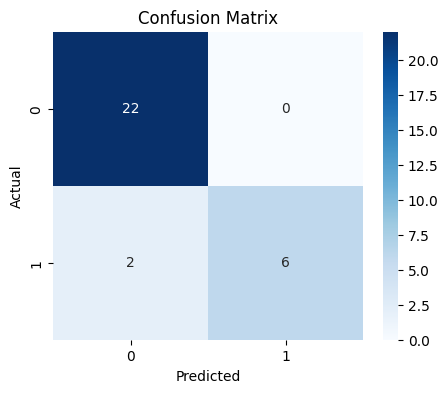

In [109]:
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Berdasarkan confusion matrix yang dihasilkan, model mampu mengklasifikasikan seluruh member non-churn dengan sangat baik, ditunjukkan oleh 22 data non-churn yang berhasil diprediksi dengan benar tanpa kesalahan. Untuk kelas churn, model masih menghasilkan beberapa kesalahan prediksi, namun secara keseluruhan performa model tetap tergolong baik, sejalan dengan nilai F1-score weighted sebesar 0.93. Hasil ini menunjukkan bahwa model memiliki kemampuan yang kuat dalam mengidentifikasi member yang tidak akan churn, serta cukup efektif dalam mendeteksi member yang berpotensi churn, sehingga dapat digunakan sebagai dasar dalam strategi retensi pelanggan.

### **8.3 ROC Curve (Receiver Operating Characteristic)**

ROC Curve digunakan untuk mengevaluasi kemampuan model dalam membedakan antara kelas churn dan non-churn pada berbagai threshold. Evaluasi ini memberikan gambaran performa model secara keseluruhan tanpa tergantung pada satu nilai threshold tertentu.

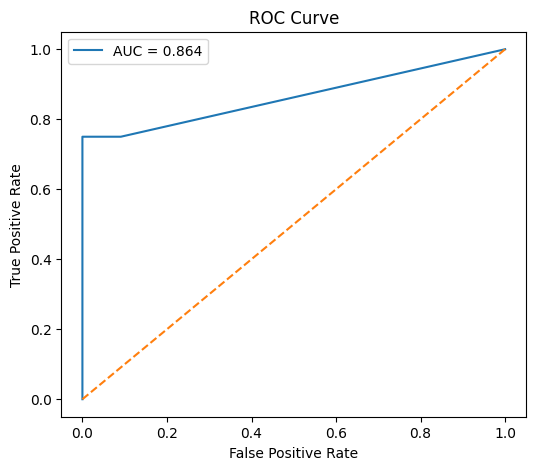

In [110]:
# Menghitung FPR dan TPR berdasarkan probabilitas prediksi kelas churn
fpr, tpr, _ = roc_curve(y_test, y_proba)
# Menghitung nilai Area Under Curve
roc_auc = roc_auc_score(y_test, y_proba)
# Visualisasi ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Berdasarkan ROC Curve yang dihasilkan, model memiliki nilai AUC sebesar **0.864**, yang menunjukkan kemampuan klasifikasi yang **baik** dalam membedakan member churn dan non-churn.

Nilai AUC yang berada di atas 0.8 menandakan bahwa model memiliki performa yang stabil dan cukup andal dalam melakukan prediksi, meskipun dataset memiliki ukuran relatif kecil dan distribusi kelas yang tidak seimbang.

Hasil ini memperkuat bahwa model tidak hanya bekerja baik pada satu threshold tertentu, tetapi mampu mempertahankan performa yang konsisten pada berbagai tingkat keputusan.

## **9. MODEL SAVING**

Pada tahap ini, model terbaik yang telah melalui proses training dan evaluasi akan disimpan agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang. Selain model, pipeline preprocessing juga ikut disimpan untuk memastikan konsistensi pada saat inferensi data baru.

In [111]:
# Menyimpan model terbaik ke file
joblib.dump(best_model, 'best_churn_model.pkl')

# Menyimpan nama fitur setelah preprocessing
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

## **10. MODEL INFERENCE**

Model inference ada pada notebook `P1M2_Nur_Cahyo_Widodo_inf.ipynb`

## **11. CONCLUSION**

Pada project ini, dilakukan pembangunan model machine learning untuk memprediksi churn member gym menggunakan dataset yang relatif kecil yaitu 150 baris dan memiliki distribusi kelas yang tidak seimbang. Proses dimulai dari data loading, exploratory data analysis (EDA), feature engineering, hingga pemodelan dan evaluasi.

Beberapa algoritma klasifikasi diuji menggunakan cross-validation untuk menentukan model terbaik. Berdasarkan hasil evaluasi, Gradient Boosting menunjukkan performa paling stabil dan unggul dibandingkan model lainnya. Selanjutnya, hyperparameter tuning dilakukan untuk meningkatkan performa model sebelum dilakukan evaluasi akhir pada data uji.

Hasil evaluasi menunjukkan bahwa model mampu memprediksi churn dengan baik, terutama dalam mengidentifikasi member non-churn, serta memiliki kemampuan diskriminasi yang cukup baik berdasarkan nilai F1-score dan AUC. Model juga berhasil digunakan untuk melakukan inference pada data member baru, sehingga menunjukkan bahwa model siapdigunakan dalam skenario nyata.

Secara keseluruhan, model yang dibangun telah memenuhi tujuan project dan dapat membantu pihak gym dalam mengidentifikasi member yang berpotensi churn untuk mendukung strategi retensi yang lebih efektif